# 🌊 台灣避難所洪水風險評估系統 (ARIA)

## 📋 專案概述

ARIA (Automated Risk Assessment and Interactive Analysis) 系統是一個完整的台灣避難所洪水風險評估解決方案，整合了地理空間分析、風險分級、統計分析和多樣化視覺化功能。

### 🎯 主要功能
- **資料清理**: 自動移除無效座標的避難所資料
- **空間分析**: 使用 gpd.sjoin 進行精確的空間連接
- **風險分級**: 基於河川距離的四級風險評估
- **統計分析**: 鄉鎮級別的風險統計和容量分析
- **視覺化**: 互動式地圖和靜態統計圖表
- **審計輸出**: 完整的 JSON 風險審計檔案

### 📊 資料來源
1. **WRA 河川多邊形**: `data/RIVERPOLY/riverpoly.shp`
2. **消防署避難所**: `data/避難收容處所點位檔案v9.csv`
3. **TGOS 鄉鎮界線**: `data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp`

### 🎨 風險等級定義
- **🔴 高風險**: 距離河川 500m 以內
- **🟠 中風險**: 距離河川 500m-1km
- **🟡 低風險**: 距離河川 1km-2km
- **🟢 安全**: 距離河川 2km 以上

## 🔧 環境設定

### 安裝依賴套件

In [1]:
# 安裝所需套件
!pip install -r requirements.txt

### 載入環境變數

In [2]:
import os
from dotenv import load_dotenv

# 載入環境變數
load_dotenv()

# 顯示重要設定
print(f"高風險緩衝區: {os.getenv('BUFFER_HIGH')}m")
print(f"中風險緩衝區: {os.getenv('BUFFER_MED')}m")
print(f"低風險緩衝區: {os.getenv('BUFFER_LOW')}m")
print(f"地圖中心: {os.getenv('MAP_CENTER_LAT')}, {os.getenv('MAP_CENTER_LON')}")

高風險緩衝區: 500m
中風險緩衝區: 1000m
低風險緩衝區: 2000m
地圖中心: 23.8, 121.0


## 🧹 步驟 1: 資料清理與準備

In [4]:
# 執行資料清理
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
from pathlib import Path
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

def clean_shelter_data(csv_path):
    """Clean shelter CSV by removing rows with 0 or null coordinates"""
    print("Loading shelter data...")
    df = pd.read_csv(csv_path)
    
    print(f"Original shelter count: {len(df)}")
    
    # Check for missing or zero coordinates
    missing_coords = df['經度'].isna() | df['緯度'].isna()
    zero_coords = (df['經度'] == 0) | (df['緯度'] == 0)
    
    # Remove rows with missing or zero coordinates
    clean_df = df[~(missing_coords | zero_coords)].copy()
    
    print(f"Cleaned shelter count: {len(clean_df)}")
    print(f"Removed {len(df) - len(clean_df)} shelters with invalid coordinates")
    
    return clean_df

def create_river_buffers(river_shapefile):
    """Create buffer zones around rivers using environment variables"""
    print("Loading river data...")
    rivers = gpd.read_file(river_shapefile)
    
    # Ensure CRS is projected for distance calculations (use Taiwan appropriate CRS)
    if rivers.crs.to_string() == 'EPSG:4326':
        rivers = rivers.to_crs('EPSG:3826')  # TWD97 / TM2 zone 121
    
    # Get buffer distances from environment variables
    buffer_high = int(os.getenv('BUFFER_HIGH', '500'))
    buffer_med = int(os.getenv('BUFFER_MED', '1000'))
    buffer_low = int(os.getenv('BUFFER_LOW', '2000'))
    
    buffer_distances = [buffer_high, buffer_med, buffer_low]
    buffer_labels = ['high', 'med', 'low']
    
    buffers = {}
    for distance, label in zip(buffer_distances, buffer_labels):
        print(f"Creating {distance}m buffer ({label} risk)...")
        buffer = rivers.geometry.buffer(distance)
        buffers[f"{distance}m"] = gpd.GeoDataFrame(geometry=buffer, crs=rivers.crs)
    
    return buffers, rivers, buffer_distances

def load_township_boundaries(township_shapefile):
    """Load township boundaries for county assignment"""
    print("Loading township boundaries...")
    try:
        townships = gpd.read_file(township_shapefile)
        # Ensure CRS is consistent - convert to projected CRS
        if townships.crs.to_string() != 'EPSG:3826':
            townships = townships.to_crs('EPSG:3826')
        print(f"Township CRS: {townships.crs}")
        return townships
    except Exception as e:
        print(f"Warning: Could not load township boundaries: {e}")
        return None

def assign_county_to_shelters(shelters_gdf, townships_gdf):
    """Assign county data to shelters using spatial join"""
    if townships_gdf is None:
        print("Skipping county assignment - no township data available")
        return shelters_gdf
    
    print("Assigning counties to shelters...")
    print(f"Shelters CRS: {shelters_gdf.crs}")
    print(f"Townships CRS: {townships_gdf.crs}")
    
    # Spatial join to assign township/county data
    shelters_with_county = gpd.sjoin(shelters_gdf, townships_gdf, how='left', predicate='intersects')
    
    # Check which shelters got county assignments
    assigned_count = len(shelters_with_county[shelters_with_county['index_right'].notna()])
    total_count = len(shelters_with_county)
    print(f"Successfully assigned county data to {assigned_count}/{total_count} shelters")
    
    return shelters_with_county

def assess_flood_risk_with_sjoin(shelters_df, river_buffers, rivers_gdf, townships_gdf=None, buffer_distances=[500, 1000, 2000]):
    """Assess flood risk using spatial joins"""
    # Convert shelter coordinates to GeoDataFrame
    geometry = [Point(lon, lat) for lon, lat in zip(shelters_df['經度'], shelters_df['緯度'])]
    shelters_gdf = gpd.GeoDataFrame(shelters_df, geometry=geometry, crs='EPSG:4326')
    
    # Convert to same CRS as rivers
    shelters_gdf = shelters_gdf.to_crs(rivers_gdf.crs)
    
    # Assign county data using spatial join
    shelters_with_county = assign_county_to_shelters(shelters_gdf, townships_gdf)
    
    # Remove shelters that failed to get county data
    if townships_gdf is not None:
        shelters_clean = shelters_with_county[shelters_with_county['index_right'].notna()].copy()
        removed_count = len(shelters_with_county) - len(shelters_clean)
        print(f"Removed {removed_count} shelters without county data")
        
        # Drop the index_right column to avoid conflicts
        shelters_clean = shelters_clean.drop(columns=['index_right'])
    else:
        shelters_clean = shelters_with_county.copy()
        removed_count = 0
    
    # Initialize risk level column
    shelters_clean['risk_level'] = 'Safe'
    
    # Assess risk levels using spatial joins (highest risk wins)
    # Sort buffer distances to ensure proper priority (smallest = highest risk)
    sorted_buffers = sorted(zip(buffer_distances, river_buffers.keys()))
    
    # Create exclusive buffer zones
    print("Creating exclusive buffer zones...")
    buffer_geometries = {}
    for i, (distance, buffer_key) in enumerate(sorted_buffers):
        buffer_geometries[distance] = river_buffers[buffer_key]
    
    # Create exclusive zones
    if len(sorted_buffers) >= 3:
        high_dist, high_key = sorted_buffers[0]
        med_dist, med_key = sorted_buffers[1] 
        low_dist, low_key = sorted_buffers[2]
        
        buffer_high_exclusive = buffer_geometries[high_dist].copy()
        buffer_med_exclusive = gpd.GeoDataFrame(
            geometry=buffer_geometries[med_dist].geometry.difference(buffer_geometries[high_dist].geometry.union_all()), 
            crs=buffer_geometries[med_dist].crs
        )
        buffer_low_exclusive = gpd.GeoDataFrame(
            geometry=buffer_geometries[low_dist].geometry.difference(buffer_geometries[med_dist].geometry.union_all()), 
            crs=buffer_geometries[low_dist].crs
        )
        
        exclusive_buffers = {
            high_key: buffer_high_exclusive,
            med_key: buffer_med_exclusive, 
            low_key: buffer_low_exclusive
        }
        
        risk_mapping = {high_key: 'High', med_key: 'Medium', low_key: 'Low'}
        
        for buffer_key, buffer_gdf in exclusive_buffers.items():
            risk_level = risk_mapping[buffer_key]
            print(f"Checking {buffer_key} buffer for {risk_level} risk...")
            
            # Spatial join to find shelters in this buffer
            shelters_in_buffer = gpd.sjoin(shelters_clean, buffer_gdf, how='inner', predicate='intersects')
            
            # Assign risk level to shelters in this buffer
            if len(shelters_in_buffer) > 0:
                shelter_indices = shelters_in_buffer.index
                shelters_clean.loc[shelter_indices, 'risk_level'] = risk_level
                print(f"Found {len(shelters_in_buffer)} shelters in {buffer_key} buffer")
    
    # Create results DataFrame
    risk_results = []
    for idx, shelter in shelters_clean.iterrows():
        risk_results.append({
            'shelter_name': shelter['避難收容處所名稱'],
            'address': shelter['避難收容處所地址'],
            'longitude': shelter['經度'],
            'latitude': shelter['緯度'],
            'capacity': shelter['預計收容人數'],
            'risk_level': shelter['risk_level'],
            'county': shelter.get('縣市及鄉鎮市區', 'Unknown'),
            'township_code': shelter.get('TOWNCODE', ''),
            'township_name': shelter.get('TOWNNAME', '')
        })
    
    return pd.DataFrame(risk_results), shelters_clean

def analyze_township_risk(risk_results):
    """Group by township and analyze risk levels"""
    print("\nAnalyzing township-level risk...")
    
    # Convert capacity to numeric, handling non-numeric values
    risk_results['capacity_numeric'] = pd.to_numeric(risk_results['capacity'], errors='coerce').fillna(0)
    
    # Group by township
    township_stats = risk_results.groupby(['township_code', 'township_name']).agg({
        'shelter_name': 'count',  # Count shelters
        'capacity_numeric': 'sum'  # Sum capacity
    }).reset_index()
    
    township_stats.columns = ['township_code', 'township_name', 'total_shelters', 'total_capacity']
    
    # Get risk level breakdown per township
    risk_counts = risk_results.groupby(['township_code', 'township_name', 'risk_level']).agg({
        'shelter_name': 'count',
        'capacity_numeric': 'sum'
    }).reset_index()
    
    risk_counts.columns = ['township_code', 'township_name', 'risk_level', 'shelter_count', 'capacity']
    
    # Pivot to get risk levels as columns
    risk_pivot = risk_counts.pivot_table(
        index=['township_code', 'township_name'],
        columns='risk_level',
        values=['shelter_count', 'capacity'],
        fill_value=0
    ).reset_index()
    
    # Flatten column names
    risk_pivot.columns = ['township_code', 'township_name', 
                         'high_shelter_count', 'low_shelter_count', 'medium_shelter_count', 'safe_shelter_count',
                         'high_capacity', 'low_capacity', 'medium_capacity', 'safe_capacity']
    
    # Merge with total stats
    township_analysis = township_stats.merge(risk_pivot, on=['township_code', 'township_name'], how='left')
    
    # Calculate safe capacity ratio
    township_analysis['safe_capacity_ratio'] = township_analysis['safe_capacity'] / township_analysis['total_capacity']
    township_analysis['safe_capacity_ratio'] = township_analysis['safe_capacity_ratio'].fillna(0)
    
    # Handle division by zero
    township_analysis['safe_capacity_ratio'] = township_analysis['safe_capacity_ratio'].replace([np.inf, -np.inf], 0)
    
    return township_analysis

def find_most_at_risk_townships(township_analysis, top_n=10):
    """Find top N most at-risk townships based on safe capacity ratio"""
    print(f"\nFinding top {top_n} most at-risk townships...")
    
    # Sort by safe capacity ratio (ascending = more at risk)
    most_at_risk = township_analysis.sort_values('safe_capacity_ratio', ascending=True).head(top_n)
    
    # Add risk ranking
    most_at_risk['risk_rank'] = range(1, len(most_at_risk) + 1)
    
    return most_at_risk

def main():
    # File paths
    data_dir = Path("data")
    shelter_csv = data_dir / "避難收容處所點位檔案v9.csv"
    river_shapefile = data_dir / "RIVERPOLY" / "riverpoly.shp"
    township_shapefile = data_dir / "鄉(鎮、市、區)界線1140318" / "TOWN_MOI_1140318.shp"
    
    # Clean shelter data
    clean_shelters = clean_shelter_data(shelter_csv)
    
    # Save cleaned data
    clean_output = data_dir / "cleaned_shelters.csv"
    clean_shelters.to_csv(clean_output, index=False, encoding='utf-8-sig')
    print(f"Cleaned shelter data saved to: {clean_output}")
    
    # Load township boundaries
    townships_gdf = load_township_boundaries(township_shapefile)
    
    # Create river buffers
    river_buffers, rivers_gdf, buffer_distances = create_river_buffers(river_shapefile)
    
    # Save buffer zones
    for buffer_name, buffer_gdf in river_buffers.items():
        buffer_output = data_dir / f"river_buffer_{buffer_name}.shp"
        buffer_gdf.to_file(buffer_output)
        print(f"Buffer saved to: {buffer_output}")
    
    # Assess flood risk using spatial joins
    risk_results, shelters_gdf = assess_flood_risk_with_sjoin(clean_shelters, river_buffers, rivers_gdf, townships_gdf, buffer_distances)
    
    # Save risk assessment results
    risk_output = data_dir / "flood_risk_assessment.csv"
    risk_results.to_csv(risk_output, index=False, encoding='utf-8-sig')
    print(f"Flood risk assessment saved to: {risk_output}")
    
    # Analyze township-level risk
    township_analysis = analyze_township_risk(risk_results)
    
    # Save township analysis
    township_output = data_dir / "township_risk_analysis.csv"
    township_analysis.to_csv(township_output, index=False, encoding='utf-8-sig')
    print(f"Township risk analysis saved to: {township_output}")
    
    # Find most at-risk townships
    most_at_risk = find_most_at_risk_townships(township_analysis, top_n=10)
    
    # Save most at-risk townships
    at_risk_output = data_dir / "most_at_risk_townships.csv"
    most_at_risk.to_csv(at_risk_output, index=False, encoding='utf-8-sig')
    print(f"Most at-risk townships saved to: {at_risk_output}")
    
    # Print summary statistics
    print("\n=== Flood Risk Assessment Summary ===")
    risk_counts = risk_results['risk_level'].value_counts()
    print(f"High risk shelters: {risk_counts.get('High', 0)}")
    print(f"Medium risk shelters: {risk_counts.get('Medium', 0)}")
    print(f"Low risk shelters: {risk_counts.get('Low', 0)}")
    print(f"Safe shelters: {risk_counts.get('Safe', 0)}")
    
    # Show most at-risk townships
    print(f"\n=== Top 10 Most At-Risk Townships ===")
    print(most_at_risk[['risk_rank', 'township_name', 'total_shelters', 'total_capacity', 'safe_capacity_ratio']].to_string(index=False))
    
    # Show high risk shelters
    high_risk = risk_results[risk_results['risk_level'] == 'High']
    if len(high_risk) > 0:
        print(f"\nHigh risk shelters (top 10):")
        print(high_risk[['shelter_name', 'address', 'county', 'capacity']].head(10).to_string(index=False))

if __name__ == "__main__":
    main()


Loading shelter data...
Original shelter count: 5973
Cleaned shelter count: 5970
Removed 3 shelters with invalid coordinates
Cleaned shelter data saved to: data\cleaned_shelters.csv
Loading township boundaries...
Township CRS: EPSG:3826
Loading river data...
Creating 500m buffer (high risk)...
Creating 1000m buffer (med risk)...
Creating 2000m buffer (low risk)...
Buffer saved to: data\river_buffer_500m.shp
Buffer saved to: data\river_buffer_1000m.shp
Buffer saved to: data\river_buffer_2000m.shp
Assigning counties to shelters...
Shelters CRS: EPSG:3826
Townships CRS: EPSG:3826
Successfully assigned county data to 5907/5970 shelters
Removed 63 shelters without county data
Creating exclusive buffer zones...
Checking 500m buffer for High risk...
Found 8169 shelters in 500m buffer
Checking 1000m buffer for Medium risk...
Found 4572 shelters in 1000m buffer
Checking 2000m buffer for Low risk...
Found 7366 shelters in 2000m buffer
Flood risk assessment saved to: data\flood_risk_assessment.cs

## 🗺️ 步驟 2: 空間分析與風險評估

In [5]:
# 讀取結果
risk_results = pd.read_csv('data/flood_risk_assessment.csv')
township_analysis = pd.read_csv('data/township_risk_analysis.csv')
most_at_risk = pd.read_csv('data/most_at_risk_townships.csv')

print("\n📊 風險評估結果:")
print(risk_results['risk_level'].value_counts().to_string())


📊 風險評估結果:
risk_level
High      2568
Medium    1358
Low       1163
Safe       818


## 📈 步驟 3: 統計分析結果

C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 38570 (\N{CJK UNIFIED IDEOGRAPH-96AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 31561 (\N{CJK UNIFIED IDEOGRAPH-7B49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 32026 (\N{CJK UNIFIED IDEOGRAPH-7D1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\3518167779.py:50: UserWarning: Glyph 20296 (\

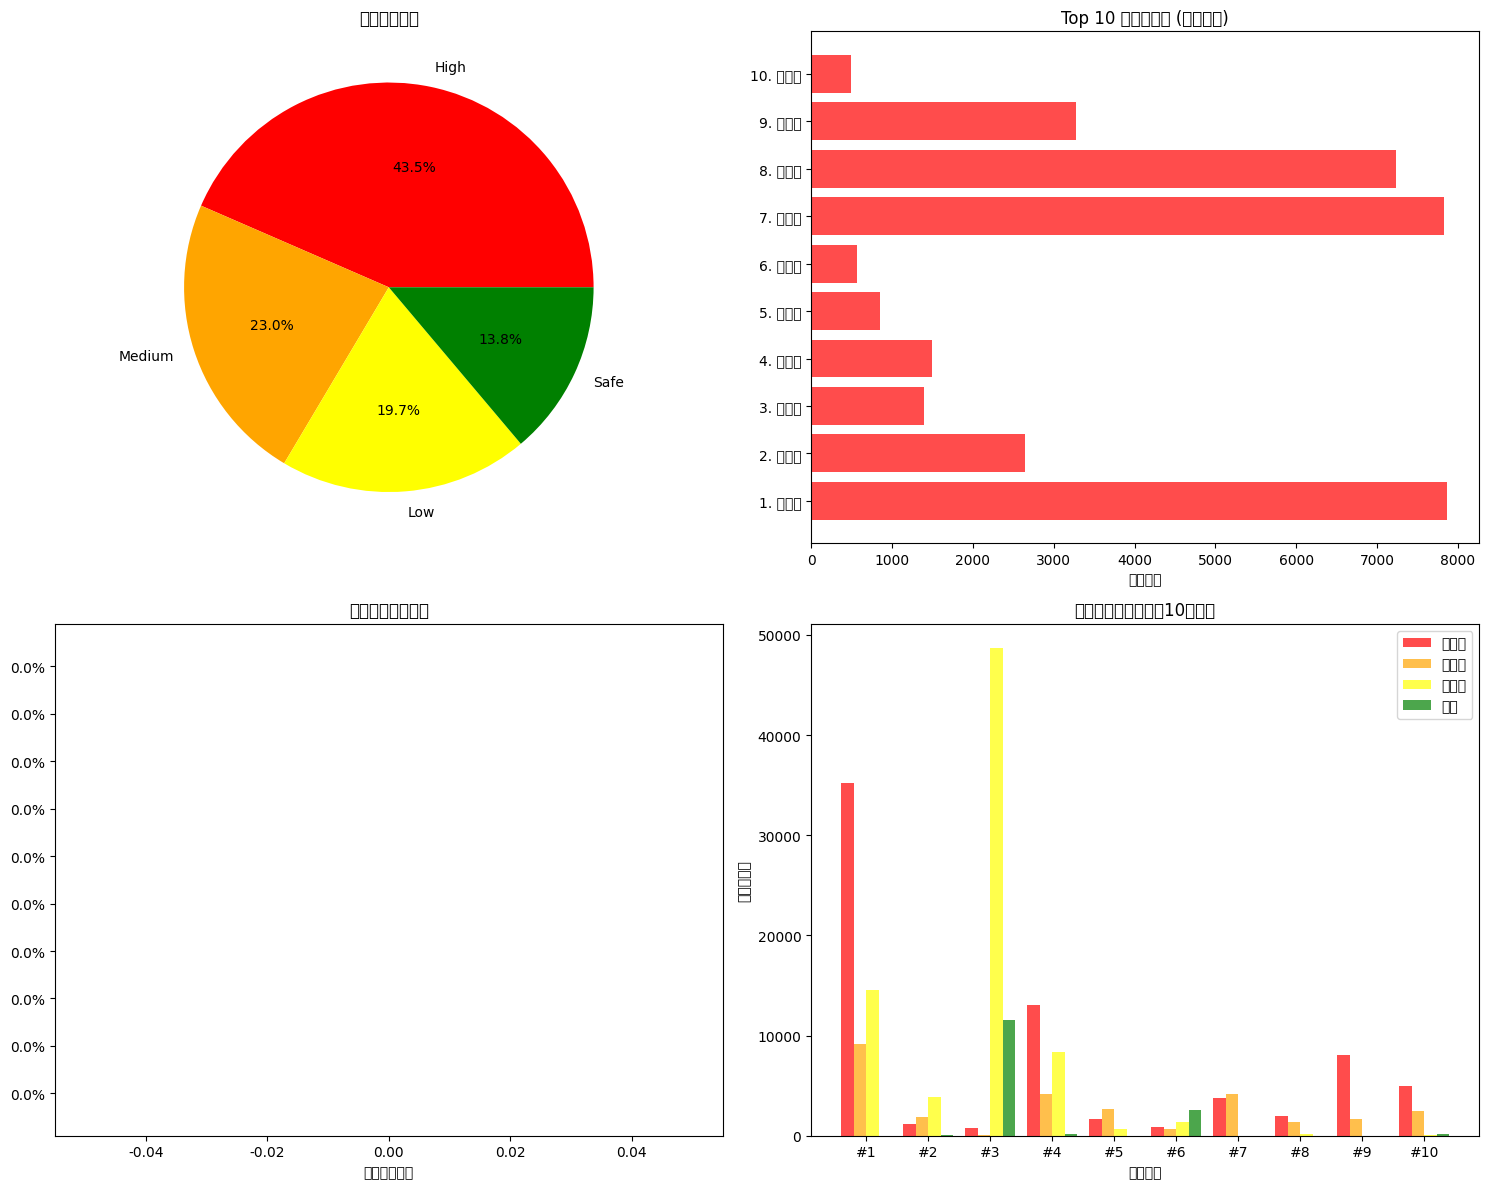

📈 統計分析圖表已生成: analysis_summary.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 風險分佈圓餅圖
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. 風險等級分佈
risk_counts = risk_results['risk_level'].value_counts()
colors = ['red', 'orange', 'yellow', 'green']
ax1.pie(risk_counts.values, labels=risk_counts.index, colors=colors, autopct='%1.1f%%')
ax1.set_title('風險等級分佈')

# 2. Top 10 高風險鄉鎮
top_10 = most_at_risk.head(10)
ax2.barh(range(len(top_10)), top_10['total_capacity'], color='red', alpha=0.7)
ax2.set_yticks(range(len(top_10)))
ax2.set_yticklabels([f"{i+1}. {name}" for i, name in enumerate(top_10['township_name'])])
ax2.set_xlabel('總收容量')
ax2.set_title('Top 10 高風險鄉鎮 (按收容量)')

# 3. 安全容量比率
safe_ratios = township_analysis.sort_values('safe_capacity_ratio', ascending=True).head(10)
ax3.barh(range(len(safe_ratios)), safe_ratios['safe_capacity_ratio'], color='darkred', alpha=0.7)
ax3.set_yticks(range(len(safe_ratios)))
ax3.set_yticklabels([f"{ratio:.1%}" for ratio in safe_ratios['safe_capacity_ratio']])
ax3.set_xlabel('安全容量比率')
ax3.set_title('最低安全容量比率')

# 4. 鄉鎮風險統計
risk_by_township = township_analysis.sort_values('total_shelters', ascending=False).head(10)
x = range(len(risk_by_township))
width = 0.2

ax4.bar([xi - width*1.5 for xi in x], risk_by_township['high_shelter_count'], width, label='高風險', color='red', alpha=0.7)
ax4.bar([xi - width*0.5 for xi in x], risk_by_township['medium_shelter_count'], width, label='中風險', color='orange', alpha=0.7)
ax4.bar([xi + width*0.5 for xi in x], risk_by_township['low_shelter_count'], width, label='低風險', color='yellow', alpha=0.7)
ax4.bar([xi + width*1.5 for xi in x], risk_by_township['safe_shelter_count'], width, label='安全', color='green', alpha=0.7)

ax4.set_xlabel('鄉鎮排名')
ax4.set_ylabel('避難所數量')
ax4.set_title('避難所數量最多的前10個鄉鎮')
ax4.legend()
ax4.set_xticks(x)
ax4.set_xticklabels([f"#{i+1}" for i in x])

plt.tight_layout()
plt.savefig('analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("📈 統計分析圖表已生成: analysis_summary.png")

## 🌐 步驟 4: 視覺化生成

In [7]:
# 執行視覺化生成
print("🎨 開始生成視覺化...")
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import json
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

def create_interactive_risk_map(risk_results, river_shapefile, township_shapefile, output_path):
    """Create interactive flood risk map using Folium"""
    print("Creating interactive risk map...")
    
    # Get map center from environment variables
    map_center_lat = float(os.getenv('MAP_CENTER_LAT', '23.8'))
    map_center_lon = float(os.getenv('MAP_CENTER_LON', '121.0'))
    map_zoom_start = int(os.getenv('MAP_ZOOM_START', '8'))
    
    # Create base map
    m = folium.Map(
        location=[map_center_lat, map_center_lon],
        zoom_start=map_zoom_start,
        tiles='OpenStreetMap'
    )
    
    # Add township boundaries
    try:
        townships = gpd.read_file(township_shapefile)
        if townships.crs.to_string() != 'EPSG:4326':
            townships = townships.to_crs('EPSG:4326')
        
        folium.GeoJson(
            townships,
            style_function=lambda x: {
                'fillColor': 'transparent',
                'color': 'gray',
                'weight': 1,
                'opacity': 0.5
            },
            tooltip=folium.GeoJsonTooltip(fields=['TOWNNAME'], aliases=['Township'])
        ).add_to(m)
        print("Added township boundaries")
    except Exception as e:
        print(f"Warning: Could not add township boundaries: {e}")
    
    # Add river polygons
    try:
        rivers = gpd.read_file(river_shapefile)
        if rivers.crs.to_string() != 'EPSG:4326':
            rivers = rivers.to_crs('EPSG:4326')
        
        folium.GeoJson(
            rivers,
            style_function=lambda x: {
                'fillColor': 'blue',
                'color': 'blue',
                'weight': 1,
                'fillOpacity': 0.6
            },
            tooltip=folium.GeoJsonTooltip(fields=['RIVER_NAME'], aliases=['River'], localize=True)
        ).add_to(m)
        print("Added river polygons")
    except Exception as e:
        print(f"Warning: Could not add river polygons: {e}")
    
    # Add buffer zones
    buffer_colors = {
        '500m': {'color': 'red', 'opacity': 0.3},
        '1000m': {'color': 'orange', 'opacity': 0.2},
        '2000m': {'color': 'yellow', 'opacity': 0.15}
    }
    
    for buffer_name, color_config in buffer_colors.items():
        buffer_file = Path(f"data/river_buffer_{buffer_name}.shp")
        if buffer_file.exists():
            try:
                buffer_gdf = gpd.read_file(buffer_file)
                if buffer_gdf.crs.to_string() != 'EPSG:4326':
                    buffer_gdf = buffer_gdf.to_crs('EPSG:4326')
                
                folium.GeoJson(
                    buffer_gdf,
                    style_function=lambda x, color=color_config: {
                        'fillColor': color['color'],
                        'color': color['color'],
                        'weight': 1,
                        'fillOpacity': color['opacity']
                    },
                    tooltip=f"{buffer_name} buffer zone"
                ).add_to(m)
                print(f"Added {buffer_name} buffer zone")
            except Exception as e:
                print(f"Warning: Could not add {buffer_name} buffer: {e}")
    
    # Define risk level colors
    risk_colors = {
        'High': 'red',
        'Medium': 'orange', 
        'Low': 'yellow',
        'Safe': 'green'
    }
    
    # Add shelter points
    for idx, shelter in risk_results.iterrows():
        try:
            lat = float(shelter['latitude'])
            lon = float(shelter['longitude'])
            risk_level = shelter['risk_level']
            
            popup_text = f"""
            <b>{shelter['shelter_name']}</b><br>
            Address: {shelter['address']}<br>
            Capacity: {shelter['capacity']}<br>
            Risk Level: {risk_level}<br>
            Township: {shelter['township_name']}<br>
            County: {shelter['county']}
            """
            
            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                popup=folium.Popup(popup_text, max_width=300),
                color='black',
                weight=1,
                fillColor=risk_colors.get(risk_level, 'gray'),
                fillOpacity=0.8
            ).add_to(m)
        except Exception as e:
            print(f"Warning: Could not add shelter {shelter['shelter_name']}: {e}")
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 140px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Risk Levels</h4>
    <i class="fa fa-circle" style="color:red"></i> High Risk (500m)<br>
    <i class="fa fa-circle" style="color:orange"></i> Medium Risk (1km)<br>
    <i class="fa fa-circle" style="color:yellow"></i> Low Risk (2km)<br>
    <i class="fa fa-circle" style="color:green"></i> Safe (>2km)<br>
    <i class="fa fa-square" style="color:blue"></i> Rivers
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Save map
    m.save(output_path)
    print(f"Interactive risk map saved to: {output_path}")

def create_static_statistics(most_at_risk, output_path):
    """Create static bar chart for top 10 high-risk townships"""
    print("Creating static statistics chart...")
    
    plt.figure(figsize=(12, 8))
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Shelter count by risk level
    risk_columns = ['high_shelter_count', 'medium_shelter_count', 'low_shelter_count', 'safe_shelter_count']
    risk_labels = ['High', 'Medium', 'Low', 'Safe']
    colors = ['red', 'orange', 'yellow', 'green']
    
    x = range(len(most_at_risk))
    width = 0.2
    
    for i, (col, label, color) in enumerate(zip(risk_columns, risk_labels, colors)):
        ax1.bar([xi + i*width for xi in x], most_at_risk[col], 
                width, label=label, color=color, alpha=0.7)
    
    ax1.set_xlabel('Township Rank')
    ax1.set_ylabel('Number of Shelters')
    ax1.set_title('Top 10 Most At-Risk Townships - Shelter Count by Risk Level')
    ax1.set_xticks([xi + width*1.5 for xi in x])
    ax1.set_xticklabels([f"#{i+1}" for i in x])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Capacity by risk level
    capacity_columns = ['high_capacity', 'medium_capacity', 'low_capacity', 'safe_capacity']
    
    for i, (col, label, color) in enumerate(zip(capacity_columns, risk_labels, colors)):
        ax2.bar([xi + i*width for xi in x], most_at_risk[col], 
                width, label=label, color=color, alpha=0.7)
    
    ax2.set_xlabel('Township Rank')
    ax2.set_ylabel('Total Capacity')
    ax2.set_title('Top 10 Most At-Risk Townships - Capacity by Risk Level')
    ax2.set_xticks([xi + width*1.5 for xi in x])
    ax2.set_xticklabels([f"#{i+1}\n{most_at_risk.iloc[i]['township_name']}" for i in x], 
                        rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Static statistics chart saved to: {output_path}")

def create_risk_audit_json(risk_results, output_path):
    """Create JSON audit file with shelter risk levels"""
    print("Creating risk audit JSON...")
    
    audit_data = {
        "metadata": {
            "total_shelters": len(risk_results),
            "assessment_date": pd.Timestamp.now().isoformat(),
            "risk_levels": ["High", "Medium", "Low", "Safe"],
            "buffer_distances": {
                "high": os.getenv('BUFFER_HIGH', '500'),
                "medium": os.getenv('BUFFER_MED', '1000'), 
                "low": os.getenv('BUFFER_LOW', '2000')
            }
        },
        "summary": {
            "risk_counts": risk_results['risk_level'].value_counts().to_dict(),
            "total_capacity": int(pd.to_numeric(risk_results['capacity'], errors='coerce').sum())
        },
        "shelters": []
    }
    
    for idx, shelter in risk_results.iterrows():
        shelter_data = {
            "id": idx,
            "name": shelter['shelter_name'],
            "address": shelter['address'],
            "longitude": float(shelter['longitude']),
            "latitude": float(shelter['latitude']),
            "capacity": int(pd.to_numeric(shelter['capacity'], errors='coerce')),
            "risk_level": shelter['risk_level'],
            "county": shelter['county'],
            "township_code": shelter['township_code'],
            "township_name": shelter['township_name']
        }
        audit_data["shelters"].append(shelter_data)
    
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(audit_data, f, ensure_ascii=False, indent=2)
    
    print(f"Risk audit JSON saved to: {output_path}")

def main():
    data_dir = Path("data")
    
    # Load data files
    risk_results = pd.read_csv(data_dir / "flood_risk_assessment.csv")
    most_at_risk = pd.read_csv(data_dir / "most_at_risk_townships.csv")
    
    # File paths
    river_shapefile = data_dir / "RIVERPOLY" / "riverpoly.shp"
    township_shapefile = data_dir / "鄉(鎮、市、區)界線1140318" / "TOWN_MOI_1140318.shp"
    
    # Output paths
    map_output = os.getenv('OUTPUT_MAP', 'risk_map.html')
    chart_output = os.getenv('OUTPUT_CHART', 'risk_map.png')
    json_output = os.getenv('OUTPUT_JSON', 'shelter_risk_audit.json')
    
    # Create visualizations
    create_interactive_risk_map(risk_results, river_shapefile, township_shapefile, map_output)
    create_static_statistics(most_at_risk, chart_output)
    create_risk_audit_json(risk_results, json_output)
    
    print("\n=== Visualization Complete ===")
    print(f"Interactive map: {map_output}")
    print(f"Static chart: {chart_output}")
    print(f"Risk audit JSON: {json_output}")

if __name__ == "__main__":
    main()


print("\n✅ 視覺化完成!")
print("📁 生成的檔案:")
print("  - risk_map.html (互動式地圖)")
print("  - risk_map.png (靜態統計圖)")
print("  - shelter_risk_audit.json (審計檔案)")
print("  - analysis_summary.png (分析摘要)")

🎨 開始生成視覺化...
Creating interactive risk map...
Added township boundaries
Added river polygons
Added 500m buffer zone
Added 1000m buffer zone
Added 2000m buffer zone
Interactive risk map saved to: risk_map.html
Creating static statistics chart...


C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 37806 (\N{CJK UNIFIED IDEOGRAPH-93AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\s9900\AppData\Local\Temp\ipykernel_20336\952974441.py:203: UserWarning: Glyph 29577 (\

Static statistics chart saved to: risk_map.png
Creating risk audit JSON...
Risk audit JSON saved to: shelter_risk_audit.json

=== Visualization Complete ===
Interactive map: risk_map.html
Static chart: risk_map.png
Risk audit JSON: shelter_risk_audit.json

✅ 視覺化完成!
📁 生成的檔案:
  - risk_map.html (互動式地圖)
  - risk_map.png (靜態統計圖)
  - shelter_risk_audit.json (審計檔案)
  - analysis_summary.png (分析摘要)


<Figure size 1200x800 with 0 Axes>

## 📊 步驟 5: 結果摘要與洞察

In [8]:
# 生成詳細的結果摘要
print("🔍 台灣避難所洪水風險評估結果摘要")
print("=" * 50)

# 基本統計
total_shelters = len(risk_results)
total_capacity = pd.to_numeric(risk_results['capacity'], errors='coerce').sum()
risk_counts = risk_results['risk_level'].value_counts()

print(f"\n📊 基本統計:")
print(f"  總避難所數量: {total_shelters:,}")
print(f"  總收容量: {total_capacity:,}")
print(f"  平均每個避難所容量: {total_capacity/total_shelters:.0f}")

print(f"\n🚨 風險分佈:")
for risk_level, count in risk_counts.items():
    percentage = (count / total_shelters) * 100
    print(f"  {risk_level}: {count:,} ({percentage:.1f}%)")

# 高風險鄉鎮分析
print(f"\n🏆 前5個最高風險鄉鎮:")
for i, (_, row) in enumerate(most_at_risk.head(5).iterrows()):
    print(f"  {i+1}. {row['township_name']}")
    print(f"     總避難所: {row['total_shelters']}, 總容量: {row['total_capacity']:,}")
    print(f"     安全容量比率: {row['safe_capacity_ratio']:.1%}")

# 關鍵洞察
print(f"\n💡 關鍵洞察:")
high_risk_percentage = (risk_counts.get('High', 0) / total_shelters) * 100
safe_percentage = (risk_counts.get('Safe', 0) / total_shelters) * 100

if high_risk_percentage > 40:
    print(f"  ⚠️  超過 {high_risk_percentage:.1f}% 的避難所位於高風險區域，需要立即關注")
if safe_percentage < 15:
    print(f"  🚨 只有 {safe_percentage:.1f}% 的避難所位於安全區域，安全容量嚴重不足")

print(f"  📍 最需要改善的區域: {most_at_risk.iloc[0]['township_name']} (安全容量比率: {most_at_risk.iloc[0]['safe_capacity_ratio']:.1%})")
print(f"  📊 建議優先在低風險區域新增避難所，特別是在安全容量比率低於20%的鄉鎮")

🔍 台灣避難所洪水風險評估結果摘要

📊 基本統計:
  總避難所數量: 5,907
  總收容量: 2,284,540
  平均每個避難所容量: 387

🚨 風險分佈:
  High: 2,568 (43.5%)
  Medium: 1,358 (23.0%)
  Low: 1,163 (19.7%)
  Safe: 818 (13.8%)

🏆 前5個最高風險鄉鎮:
  1. 平鎮區
     總避難所: 48, 總容量: 7,870
     安全容量比率: 0.0%
  2. 山上區
     總避難所: 9, 總容量: 2,650
     安全容量比率: 0.0%
  3. 玉井區
     總避難所: 8, 總容量: 1,400
     安全容量比率: 0.0%
  4. 楠西區
     總避難所: 5, 總容量: 1,490
     安全容量比率: 0.0%
  5. 南化區
     總避難所: 9, 總容量: 850
     安全容量比率: 0.0%

💡 關鍵洞察:
  ⚠️  超過 43.5% 的避難所位於高風險區域，需要立即關注
  🚨 只有 13.8% 的避難所位於安全區域，安全容量嚴重不足
  📍 最需要改善的區域: 平鎮區 (安全容量比率: 0.0%)
  📊 建議優先在低風險區域新增避難所，特別是在安全容量比率低於20%的鄉鎮


## 📁 輸出檔案清單

### 主要輸出檔案:
- `data/cleaned_shelters.csv` - 清理後的避難所資料
- `data/flood_risk_assessment.csv` - 個別避難所風險評估
- `data/township_risk_analysis.csv` - 鄉鎮級別風險統計
- `data/most_at_risk_townships.csv` - 最高風險鄉鎮排名
- `risk_map.html` - 互動式 Folium 地圖
- `risk_map.png` - 靜態統計圖表
- `shelter_risk_audit.json` - 完整風險審計 JSON
- `analysis_summary.png` - 分析摘要圖表

### 緩衝區 Shapefile:
- `data/river_buffer_500m.shp` - 高風險緩衝區
- `data/river_buffer_1000m.shp` - 中風險緩衝區
- `data/river_buffer_2000m.shp` - 低風險緩衝區

## 🔄 使用說明

### 完整執行流程:
1. **環境準備**: 確保所有依賴套件已安裝
2. **設定參數**: 修改 `.env` 檔案中的緩衝區距離和輸出路徑
3. **執行分析**: 按順序執行上述所有程式碼區塊
4. **查看結果**: 開啟 `risk_map.html` 查看互動式地圖

### 自訂設定:
- 修改 `.env` 檔案中的 `BUFFER_*` 參數調整緩衝區距離
- 修改 `MAP_CENTER_*` 參數調整地圖中心點
- 修改 `OUTPUT_*` 參數自訂輸出檔案名稱

### 注意事項:
- 確保所有資料檔案存在於正確路徑
- 系統使用 TWD97/EPSG:3826 座標系統進行距離計算
- 中文顯示可能需要適當的字體支援
- 大量資料處理時可能需要較長時間